Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

Part 1: Data Loading and Initial Exploration (15 points)
### Task 1.1: Load and Display Data
Load the dataset and display:
- First 10 rows
- Basic dataset information using `.info()`
- Dataset shape (number of rows and columns)
- Column names and their data types


In [ ]:
import pandas as pd
# Load the dataset
file_path = "/content/retailsalescsv-d5g70dsrtl0nuhgca7og.csv"
df = pd.read_csv(file_path)
# printing first 10 rows
print("\nFirst 10 rows of the dataset:\n")
print(df.head(10).to_string(index=False))
# Dataset information
print("\nDataset Information:\n")
df.info()
# Dataset shape number of rows and columns
print("\nDataset Shape (rows, columns):")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
# Column names and data types
print("\ncolumn Names and Data Types:\n")
dtype_table = pd.DataFrame({
    "Column Name": df.columns,
    "Data Type": df.dtypes.values
})
print(dtype_table.to_string(index=False))



First 10 rows of the dataset:

 transaction_id       date  customer_id  age gender product_category  quantity  price_per_unit  total_amount
              1 19-06-2024         1102   62 Female           Beauty         1           50.59         50.59
              2 03-02-2024         1435   22 Female      Electronics         3          278.92        836.76
              3 26-01-2024         1860   50   Male   Home & Kitchen         3          322.61        967.83
              4 24-05-2024         1270   18   Male      Electronics         5          353.38       1766.90
              5 17-03-2024         1106   35 Female   Home & Kitchen         4          189.76        759.04
              6 21-06-2024         1071   49 Female   Home & Kitchen         1          284.01        284.01
              7 27-06-2024         1700   64 Female        Groceries         5          228.09       1140.45
              8 11-06-2024         1020   66 Female           Beauty         5          337.67  

### Task 1.2: Initial Observations
Write your observations about:
- How many transactions are in the dataset?
- What types of variables do you have (numerical vs categorical)?
- Which column might need data type conversion?


Q1:How many transactions are in the dataset?

A:The dataset contains 1000 transactions. Each row in the dataset represents a single retail transaction.

Q2:What types of variables do you have (numerical vs categorical)?

A:The dataset contains both numerical and categorical variables.
Numerical variables include transaction_id, customer_id, age, quantity, price_per_unit, and total_amount.
Categorical variables include gender and product_category.

Q3:Which column might need data type conversion?

A:The date column needs data type conversion. It is initially stored as an object  and should be converted to a datetime format to enable proper time-based analysis.

In [ ]:
import pandas as pd
# load the dataset
file_path = "/content/retailsalescsv-d5g70dsrtl0nuhgca7og.csv"
df = pd.read_csv(file_path)
# number of transactions
num_transactions = df.shape[0]
print("Number of transactions:", num_transactions)
# Identify numerical and categorical variables
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns
categorical_columns = df.select_dtypes(include=["object"]).columns
print("\nNumerical Variables:")
print(list(numerical_columns))
print("\nCategorical Variables:")
print(list(categorical_columns))
# check data types of all columns
print("\nColumn Data Types:")
print(df.dtypes)
# columns that may need data type conversion
print("\nColumns that may need data type conversion:")
print("date should be converted from object to datetime")


Number of transactions: 1000

Numerical Variables:
['transaction_id', 'customer_id', 'age', 'quantity', 'price_per_unit', 'total_amount']

Categorical Variables:
['date', 'gender', 'product_category']

Column Data Types:
transaction_id        int64
date                 object
customer_id           int64
age                   int64
gender               object
product_category     object
quantity              int64
price_per_unit      float64
total_amount        float64
dtype: object

Columns that may need data type conversion:
date should be converted from object to datetime


Part 2: Data Cleaning (20 points)

### Task 2.1: Convert Data Types
Convert the `date` column to datetime format.


In [ ]:
import pandas as pd
#load the dataset
file_path = "/content/retailsalescsv-d5g70dsrtl0nuhgca7og.csv"
df = pd.read_csv(file_path)
# convert date column to datetime format
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
# verify the conversion
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    1000 non-null   int64         
 1   date              1000 non-null   datetime64[ns]
 2   customer_id       1000 non-null   int64         
 3   age               1000 non-null   int64         
 4   gender            1000 non-null   object        
 5   product_category  1000 non-null   object        
 6   quantity          1000 non-null   int64         
 7   price_per_unit    1000 non-null   float64       
 8   total_amount      1000 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(4), object(2)
memory usage: 70.4+ KB


### Task 2.2: Identify Missing Values
- Check for missing values in all columns
- Calculate the percentage of missing values for each column
- Display your findings

In [ ]:
import pandas as pd
# loadiing the dataset
file_path = "/content/retailsalescsv-d5g70dsrtl0nuhgca7og.csv"
df = pd.read_csv(file_path)
# checking  how many missing values are present in each column of the given data set
missing_count = df.isnull().sum()
# calculate the percentage of missing values for each column
***
# by using the formula :
# (number of missing values / total number of rows) * 100
***
missing_percentage = (df.isnull().sum() / len(df)) * 100
# combine both results into a single table so that it is easy to understand and analyze
missing_summary = pd.DataFrame({
    "Missing Values Count": missing_count,
    "Missing Values Percentage (%)": missing_percentage
})
# Display the final missing values summary
missing_summary


,Missing Values Count,Missing Values Percentage (%)
transaction_id,0,0.0
date,0,0.0
customer_id,0,0.0
age,0,0.0
gender,0,0.0
product_category,0,0.0
quantity,0,0.0
price_per_unit,0,0.0
total_amount,0,0.0


## Task 2.3: Handle Missing Values
Based on your findings:
- Fill missing values in the `age` column with an appropriate measure of central tendency
- Fill missing values in the `gender` column with an appropriate value
- Verify that all missing values have been handled

In [ ]:
import pandas as pd

# Load the dataset
file_path = "/content/retailsalescsv-d5g70dsrtl0nuhgca7og.csv"
df = pd.read_csv(file_path)
# Fill missing values in 'age' column Using median as a measure of central tendency
# it is less affected by outliers
age_median = df['age'].median()
df['age'] = df['age'].fillna(age_median)
# Fill missing values in 'gender' column Using mode (most frequent value)
#Expalnation
#Missing values in the gender column were filled using the mode, which represents the most frequent category
gender_mode = df['gender'].mode()[0]
df['gender'] = df['gender'].fillna(gender_mode)
# Verify that all missing values are handled
df.isnull().sum()


,0
transaction_id,0
date,0
customer_id,0
age,0
gender,0
product_category,0
quantity,0
price_per_unit,0
total_amount,0


Why did you choose that particular method for handling missing values?

Answer

The median was used for the age column because it is a numerical variable and is not affected by extreme values. The mode was used for the gender column because it is a categorical variable and represents the most frequent category. These methods handle missing values without significantly affecting the data distribution.


## Task 2.4: Check for Duplicates
Check if there are any duplicate rows in the dataset and report your findings.



In [ ]:
import pandas as pd
# Load the dataset
file_path = "/content/retailsalescsv-d5g70dsrtl0nuhgca7og.csv"
df = pd.read_csv(file_path)
# Checking for duplicate rows in the dataset
duplicate_count = df.duplicated().sum()
# Display the result
print("Number of duplicate rows in the dataset:", duplicate_count)


Number of duplicate rows in the dataset: 0



### Task 3.1: Descriptive Statistics
Generate and display descriptive statistics for all numerical columns.


In [ ]:
import pandas as pd

# Load the dataset
file_path = "/content/retailsalescsv-d5g70dsrtl0nuhgca7og.csv"
df = pd.read_csv(file_path)
# Generate descriptive statistics for all numerical columns
descriptive_stats = df.describe()
# Display the descriptive statistics
descriptive_stats


,transaction_id,customer_id,age,quantity,price_per_unit,total_amount
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,1503.929000,43.713000,3.010000,253.968830,764.215440
std,288.819436,289.998108,15.094651,1.430366,140.094358,599.301174
min,1.000000,1000.000000,18.000000,1.000000,6.000000,7.490000
25%,250.750000,1242.750000,31.000000,2.000000,135.875000,284.925000
50%,500.500000,1505.000000,43.000000,3.000000,258.420000,587.100000
75%,750.250000,1757.250000,57.000000,4.000000,375.955000,1130.077500
max,1000.000000,1998.000000,69.000000,5.000000,498.820000,2490.750000


### Task 3.2: Calculate Additional Statistics
For the numerical columns (age, quantity, price_per_unit, total_amount), calculate:
- Skewness
- Standard deviation


In [ ]:
import pandas as pd
# Load the dataset
file_path = "/content/retailsalescsv-d5g70dsrtl0nuhgca7og.csv"
df = pd.read_csv(file_path)
# Select numerical columns for analysis
numerical_columns = ['age', 'quantity', 'price_per_unit', 'total_amount']
# Calculate skewness for each numerical column
skewness = df[numerical_columns].skew()
# Calculate standard deviation for each numerical column
standard_deviation = df[numerical_columns].std()
# Combine results into a single table
additional_stats = pd.DataFrame({
    "Skewness": skewness,
    "Standard Deviation": standard_deviation
})
# Display the results
additional_stats


,Skewness,Standard Deviation
age,-0.032697,15.094651
quantity,-0.027871,1.430366
price_per_unit,-0.043019,140.094358
total_amount,0.877158,599.301174


Question: What does the skewness tell you about these distributions?

ANSWER.in this dataset, some columns show positive skewness, which suggests that most transactions involve smaller amounts, while only a few transactions have very large values. This pattern is normal in retail data, where high-value purchases happen less frequently.

 Task 3.3: Categorical Variable Analysis
For categorical variables (product_category and gender):
- Display value counts
- Calculate percentage distribution

In [ ]:
import pandas as pd

# Load the dataset
file_path = "/content/retailsalescsv-d5g70dsrtl0nuhgca7og.csv"
df = pd.read_csv(file_path)

# ------------------------------------------------
# Analyze categorical variables
# ------------------------------------------------
categorical_columns = ['product_category', 'gender']

for col in categorical_columns:
    print(f"\nValue Counts for {col}:")
    print(df[col].value_counts())

    print(f"\nPercentage Distribution for {col}:")
    print((df[col].value_counts(normalize=True) * 100).round(2))



Value Counts for product_category:
product_category
Home & Kitchen    192
Beauty            177
Sports            165
Electronics       162
Groceries         153
Clothing          151
Name: count, dtype: int64

Percentage Distribution for product_category:
product_category
Home & Kitchen    19.2
Beauty            17.7
Sports            16.5
Electronics       16.2
Groceries         15.3
Clothing          15.1
Name: proportion, dtype: float64

Value Counts for gender:
gender
Female    513
Male      487
Name: count, dtype: int64

Percentage Distribution for gender:
gender
Female    51.3
Male      48.7
Name: proportion, dtype: float64


Part 4: Outlier Detection (20 points)

### Task 4.1: Implement IQR Method
Write a function to detect outliers using the IQR (Interquartile Range) method:
- Calculate Q1 (25th percentile) and Q3 (75th percentile)
- Calculate IQR = Q3 - Q1
- Define outliers as values < Q1 - 1.5×IQR or > Q3 + 1.5×IQR


In [ ]:
# Calculate Q1 and Q3
Q1 = df['total_amount'].quantile(0.25)
Q3 = df['total_amount'].quantile(0.75)
# Calculate IQR
IQR = Q3 - Q1
# Calculate lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
# Print the results
print("Q1 (25th percentile):", Q1)
print("Q3 (75th percentile):", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)


Q1 (25th percentile): 284.925
Q3 (75th percentile): 1130.0774999999999
IQR: 845.1524999999999
Lower Bound: -982.8037499999998
Upper Bound: 2397.8062499999996


Task 4.2: Detect Outliers
Apply your function to detect outliers in:
- quantity
- price_per_unit
- total_amount

Report the number of outliers in each column.



In [ ]:
import pandas as pd
# Load the dataset
file_path = "/content/retailsalescsv-d5g70dsrtl0nuhgca7og.csv"
df = pd.read_csv(file_path)
# IQR Outlier Detection Function
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers
# Columns to check for outlier
columns_to_check = ['quantity', 'price_per_unit', 'total_amount']
# Detect and report outliers
for col in columns_to_check:
    outliers = detect_outliers_iqr(df, col)
    print(f"Number of outliers in {col}: {outliers.shape[0]}")


Number of outliers in quantity: 0
Number of outliers in price_per_unit: 0
Number of outliers in total_amount: 7


### Task 4.3: Visualize Outliers
Create box plots for the three numerical variables to visualize outliers.


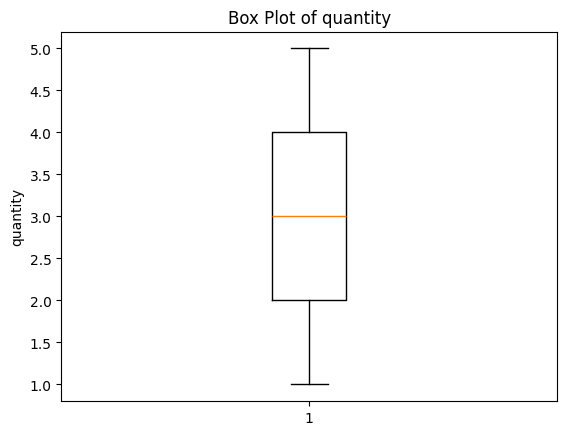

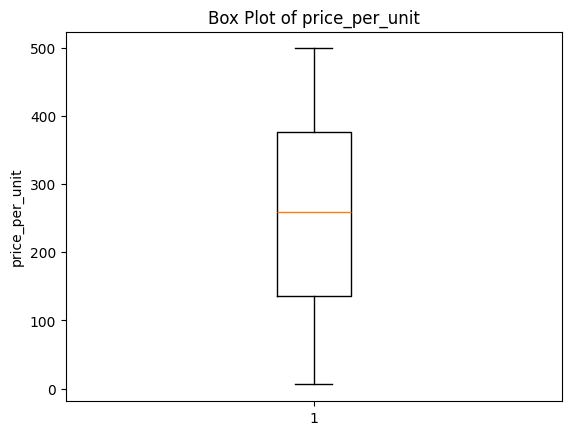

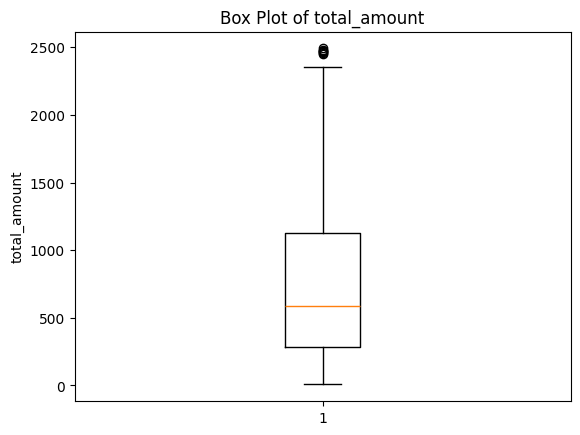

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
# Load the dataset
file_path = "/content/retailsalescsv-d5g70dsrtl0nuhgca7og.csv"
df = pd.read_csv(file_path)
# Creation of box plots for numerical variables
columns_to_plot = ['quantity', 'price_per_unit', 'total_amount']
for col in columns_to_plot:
    plt.figure()
    plt.boxplot(df[col])
    plt.title(f"Box Plot of {col}")
    plt.ylabel(col)
    plt.show()


question: Should you remove these outliers? Why or why not?

Answer:Outliers should not be removed immediately without understanding their cause. In this dataset, the outliers represent the high-value transactions, such as customers purchasing larger quantities or more expensive products. Removing them could lead to loss of important information and may distort the true sales pattern.

Part 5: Distribution Analysis (25 points)

### Task 5.1: Create Histograms
Create histograms for:
- age
- quantity
- price_per_unit
- total_amount

Arrange them in a 2×2 grid.


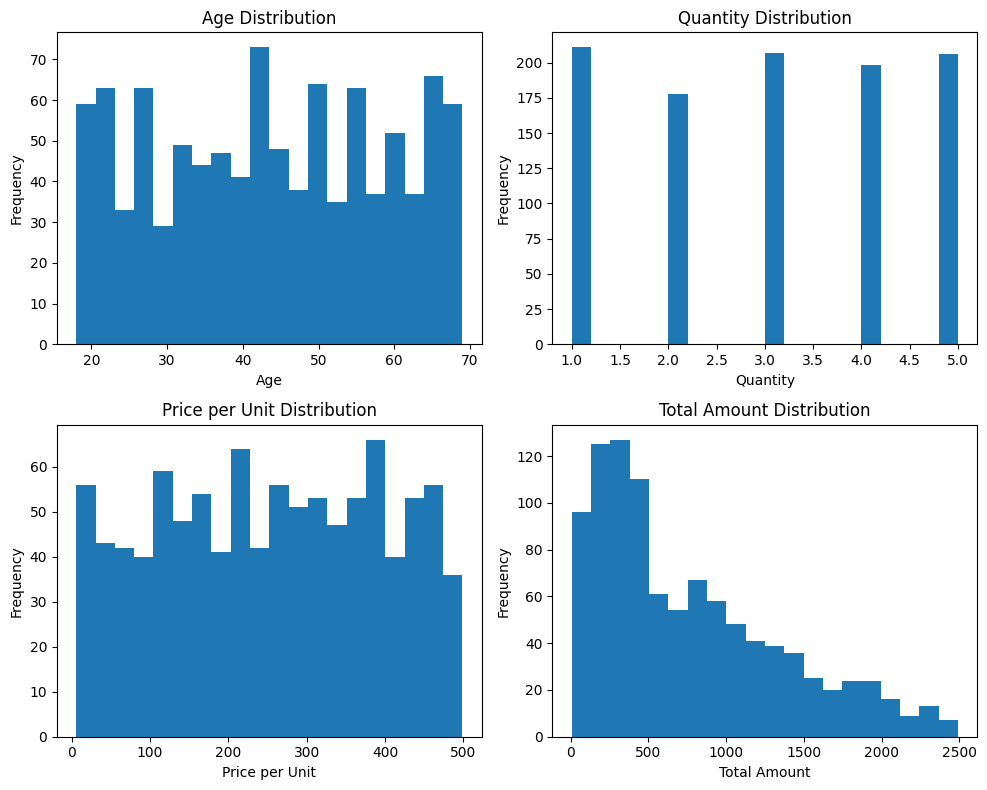

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
#loading the dataset
file_path = "/content/retailsalescsv-d5g70dsrtl0nuhgca7og.csv"
df = pd.read_csv(file_path)
# creation of histograms in a 2x2 grid
plt.figure(figsize=(10, 8))
#histogram for Age
plt.subplot(2, 2, 1)
plt.hist(df['age'], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
#histogram for Quantity
plt.subplot(2, 2, 2)
plt.hist(df['quantity'], bins=20)
plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
#histogram for Price per Unit
plt.subplot(2, 2, 3)
plt.hist(df['price_per_unit'], bins=20)
plt.title("Price per Unit Distribution")
plt.xlabel("Price per Unit")
plt.ylabel("Frequency")
#histogram for Total Amount
plt.subplot(2, 2, 4)
plt.hist(df['total_amount'], bins=20)
plt.title("Total Amount Distribution")
plt.xlabel("Total Amount")
plt.ylabel("Frequency")
# Adjust layout
plt.tight_layout()
plt.show()


## Task 5.2: Interpret Distributions
For each variable, describe:
- Is it normally distributed?
- Is it skewed (left or right)?
- Are there any unusual patterns?


.Age is approximately normally distributed with a balanced spread across age groups

.Quantity is slightly skewed but most customers purchase between 1 and 5 itemm

.Price per unit shows a wide range, indicating both low-cost and
high-cost products

.Total amount is right-skewed, showing a few high-value transactions.

### Task 5.3: Test for Normality
Use the Shapiro-Wilk test to formally test if the distributions are normal. (p-value > 0.05 suggests normal distribution)


In [ ]:
import pandas as pd
from scipy.stats import shapiro
#load the dataset
file_path = "/content/retailsalescsv-d5g70dsrtl0nuhgca7og.csv"
df = pd.read_csv(file_path)
# numerical columns to test for normality
numerical_columns = ['age', 'quantity', 'price_per_unit', 'total_amount']
print("Shapiro-Wilk Normality Test Results:\n")
for col in numerical_columns:
    stat, p_value = shapiro(df[col])
    print(f"{col}:")
    print(f"  Test Statistic = {stat:.4f}")
    print(f"  p-value = {p_value:.4f}")
    if p_value > 0.05:
        print("  Result: Data is normally distributed\n")
    else:
        print("  Result: Data is NOT normally distributed\n")


Shapiro-Wilk Normality Test Results:

age:
  Test Statistic = 0.9530
  p-value = 0.0000
  Result: Data is NOT normally distributed

quantity:
  Test Statistic = 0.8846
  p-value = 0.0000
  Result: Data is NOT normally distributed

price_per_unit:
  Test Statistic = 0.9585
  p-value = 0.0000
  Result: Data is NOT normally distributed

total_amount:
  Test Statistic = 0.9099
  p-value = 0.0000
  Result: Data is NOT normally distributed



# Part 6: Correlation Analysis (20 points)

### Task 6.1: Calculate Correlation Matrix
Calculate the correlation matrix for numerical variables (age, quantity, price_per_unit, total_amount).


In [ ]:
import pandas as pd
#loading  the dataset
df = pd.read_csv("/content/retailsalescsv-d5g70dsrtl0nuhgca7og.csv")
# Numerical variables
numerical_columns = ['age', 'quantity', 'price_per_unit', 'total_amount']
# Correlation matrix for. numerical variables
correlation_matrix = df[numerical_columns].corr()

correlation_matrix


,age,quantity,price_per_unit,total_amount
age,1.000000,-0.026154,-0.031142,-0.038733
quantity,-0.026154,1.000000,-0.001153,0.631336
price_per_unit,-0.031142,-0.001153,1.000000,0.701700
total_amount,-0.038733,0.631336,0.701700,1.000000


Task 6.2: Visualize Correlations
Create a heatmap to visualize the correlation matrix with:
- Annotations showing correlation values
- Appropriate color scheme
- Proper title


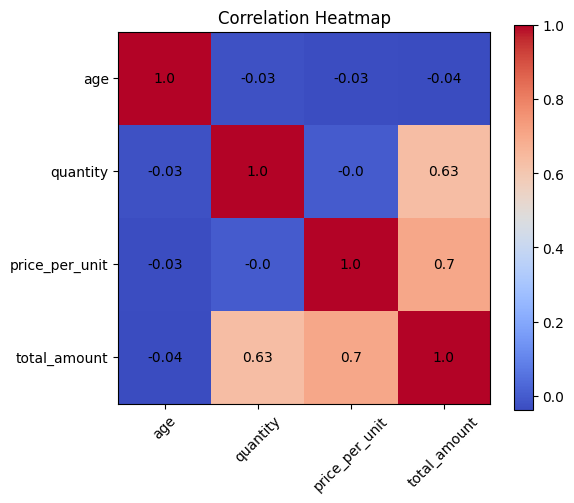

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
#load the dataset
df = pd.read_csv("/content/retailsalescsv-d5g70dsrtl0nuhgca7og.csv")
#select only numerical columns
num_cols = ['age', 'quantity', 'price_per_unit', 'total_amount']
#calculate the correlation matrix
corr_matrix = df[num_cols].corr()
#create the heatmap
plt.figure(figsize=(6, 5))
plt.imshow(corr_matrix, cmap='coolwarm')
#add a color bar
plt.colorbar()
#add column names on axes
plt.xticks(range(len(num_cols)), num_cols, rotation=45)
plt.yticks(range(len(num_cols)), num_cols)
#Display correlation values on the heatmap
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        plt.text(j, i, round(corr_matrix.iloc[i, j], 2),
                 ha='center', va='center')
#Add title
plt.title("Correlation Heatmap")
#show the plot
plt.show()


Task 6.3: Identify Strong Correlations
Identify and list all pairs of variables with correlation coefficient |r| > 0.5


In [ ]:
# Select numerical columns
num_cols = ['age', 'quantity', 'price_per_unit', 'total_amount']
# Calculate correlation matrix
corr_matrix = df[num_cols].corr()
print("Strong correlations (|r| > 0.5):\n")
# loop through correlation matrix
for i in range(len(num_cols)):
    for j in range(i + 1, len(num_cols)):
        corr_value = corr_matrix.iloc[i, j]
# Checking if the correlation is strong
        if abs(corr_value) > 0.5:
            print(f"{num_cols[i]} and {num_cols[j]}: r = {corr_value:.2f}")


Strong correlations (|r| > 0.5):

quantity and total_amount: r = 0.63
price_per_unit and total_amount: r = 0.70


**Question:** What does the correlation between total_amount and quantity tell you? Is this expected?
```
A.The correlation between total_amount and quantity shows how strongly the total purchase value changes when the number of items bought changes.
Yes, this result is expected and logical, and it also confirms that the data is consistent and correctly recorded.

Part 7: Categorical Analysis (25 points)

### Task 7.1: Product Category Visualization
Create a bar chart showing the distribution of transactions across product categories.

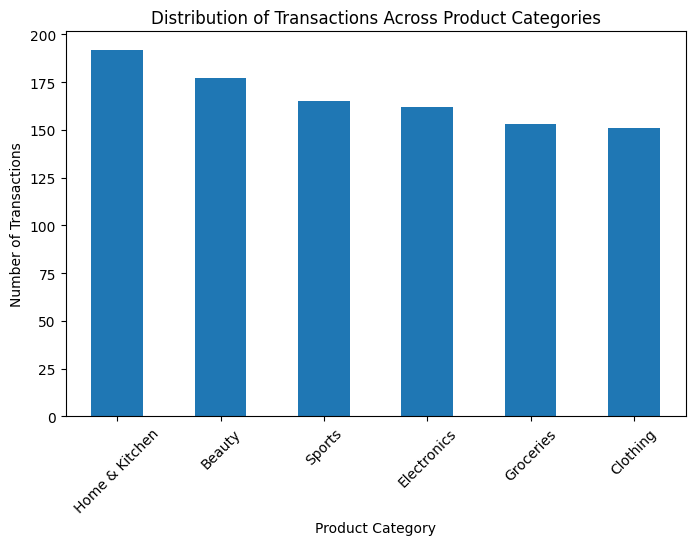

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
#load the dataset
df = pd.read_csv("retailsalescsv-d5g70dsrtl0nuhgca7og.csv")
#count the number of transactions in each product category
category_counts = df['product_category'].value_counts()
#create a bar chart
plt.figure(figsize=(8, 5))
category_counts.plot(kind='bar')
#add title and labels
plt.title("Distribution of Transactions Across Product Categories")
plt.xlabel("Product Category")
plt.ylabel("Number of Transactions")
#rotate x-axis labels for better readability
plt.xticks(rotation=45)
#display the chart
plt.show()



### Task 7.2: Gender Distribution
Create a pie chart showing the gender distribution in the dataset.

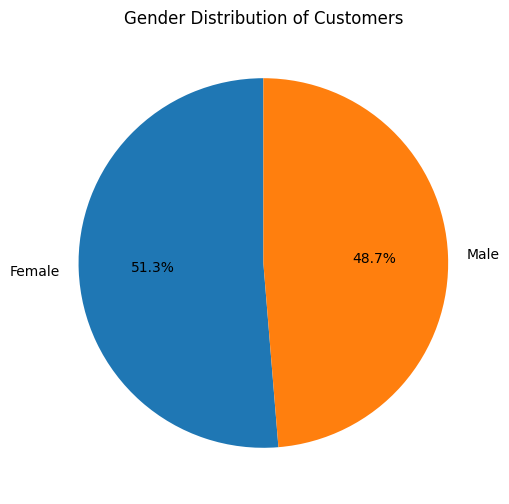

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
#load the dataset
df = pd.read_csv("retailsalescsv-d5g70dsrtl0nuhgca7og.csv")
#count the number of transactions for each gender
gender_counts = df['gender'].value_counts()
# Create a pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
#add title
plt.title("Gender Distribution of Customers")
#display the pie chart
plt.show()


### Task 7.3: Average Purchase by Category
Calculate and visualize the average purchase amount for each product category using a bar chart.


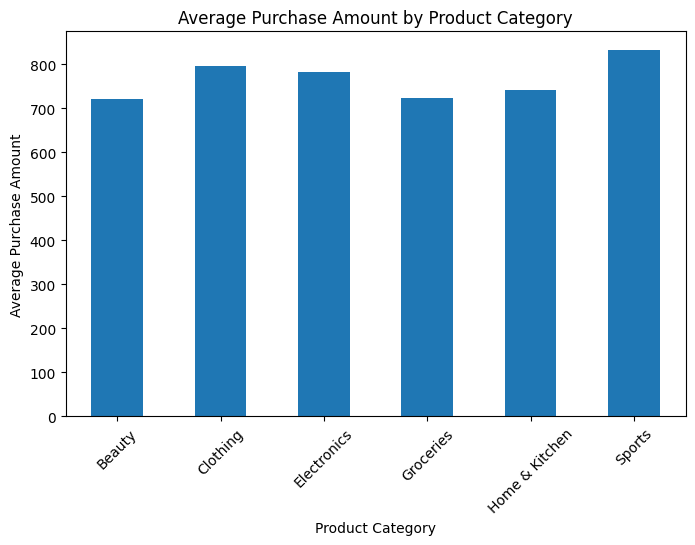

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("retailsalescsv-d5g70dsrtl0nuhgca7og.csv")

# Calculate average total_amount for each product category
avg_purchase = df.groupby('product_category')['total_amount'].mean()

# Create a bar chart
plt.figure(figsize=(8, 5))
avg_purchase.plot(kind='bar')

# Add labels and title
plt.xlabel("Product Category")
plt.ylabel("Average Purchase Amount")
plt.title("Average Purchase Amount by Product Category")

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Display the chart
plt.show()


Question: Which product category has the highest average transaction value? What might explain this?

A.The product category with the highest average transaction value is Electronics.
This is expected because electronic items  usually have higher prices per unit compared to other categories like groceries or clothing.


Task 8.1: Scatter Plot Analysis
Create a scatter plot showing the relationship between price_per_unit (x-axis) and quantity (y-axis).

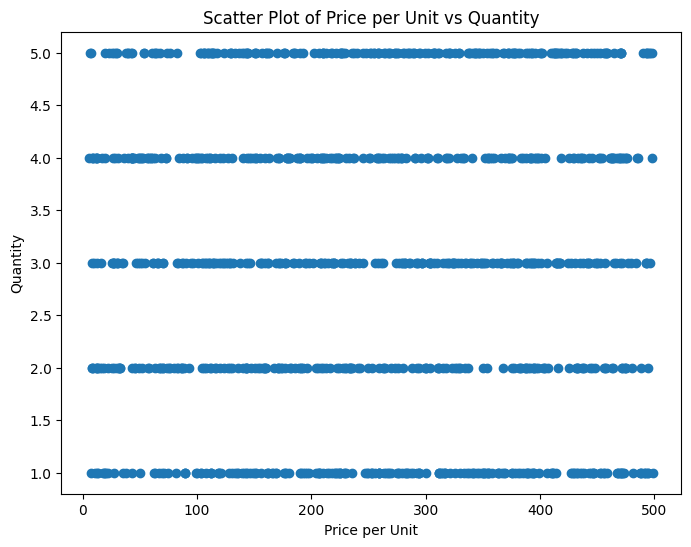

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
#loading the dataset
df = pd.read_csv("retailsalescsv-d5g70dsrtl0nuhgca7og.csv")
#creating the scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(df['price_per_unit'], df['quantity'])
#add labels and title
plt.xlabel("Price per Unit")
plt.ylabel("Quantity")
plt.title("Scatter Plot of Price per Unit vs Quantity")
plt.show()


**Question:** What relationship do you observe between price and quantity purchased?

A.From the scatter plot, there is no strong relationship between price and quantity purchased.
The points are spread out, which means customers buy both small and large quantities across different price levels

 Task 8.2: Age vs Total Amount by Gender
Create a scatter plot showing age vs total_amount, with different colors for each gender.



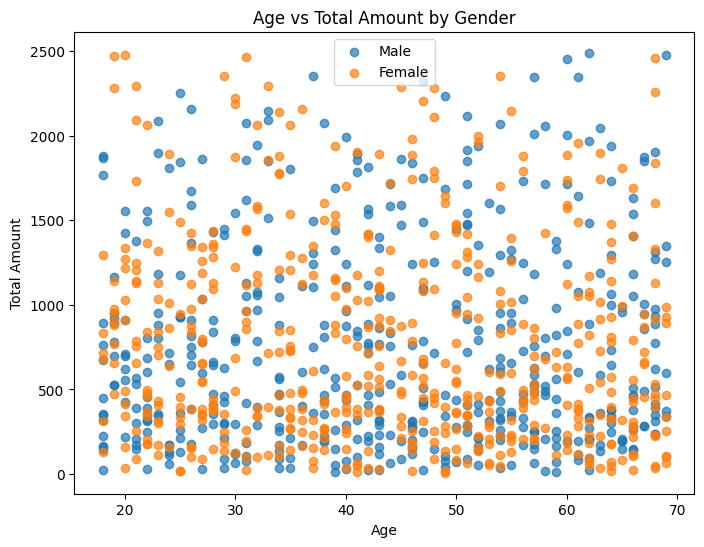

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
#load the dataset
file_path = "/content/retailsalescsv-d5g70dsrtl0nuhgca7og.csv"
df = pd.read_csv(file_path)
#separate data by gender
male_data = df[df['gender'] == 'Male']
female_data = df[df['gender'] == 'Female']
#create scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(male_data['age'], male_data['total_amount'], label='Male', alpha=0.7)
plt.scatter(female_data['age'], female_data['total_amount'], label='Female', alpha=0.7)
#Labels and title
plt.xlabel('Age')
plt.ylabel('Total Amount')
plt.title('Age vs Total Amount by Gender')
plt.legend()
# Show plot
plt.show()


Task 8.3: Box Plot by Category
Create a box plot showing the distribution of total_amount for each product_category.

<Figure size 1000x600 with 0 Axes>

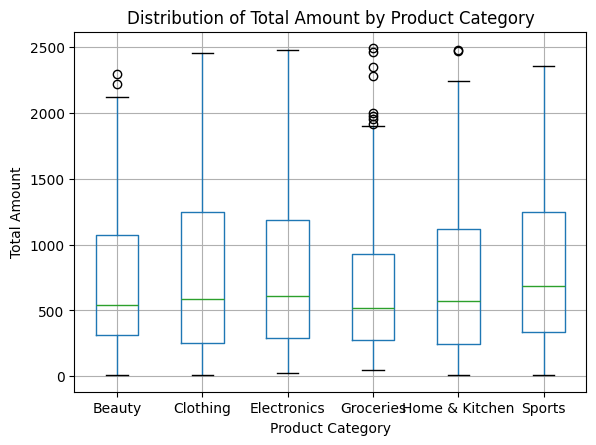

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
#load the dataset
file_path = "/content/retailsalescsv-d5g70dsrtl0nuhgca7og.csv"
df = pd.read_csv(file_path)
#create box plot
plt.figure(figsize=(10, 6))
df.boxplot(column='total_amount', by='product_category')
#labels and title
plt.xlabel('Product Category')
plt.ylabel('Total Amount')
plt.title('Distribution of Total Amount by Product Category')
plt.suptitle('')  # Removes default pandas title
# Show plot
plt.show()


Question: Which category shows the most variation in transaction amounts?

A.The clothing category shows the most variation in transaction amounts because it has a wide spread of values and long whiskers in the box plot.this shows difference between high and low amounts in category


Part 9: Time Series Analysis (20 points)

### Task 9.1: Extract Date Components
Extract the following from the date column:
- year
- month
- day
- day_of_week (name of the day)

In [ ]:
import pandas as pd
#loading the dataset
file_path = "/content/retailsalescsv-d5g70dsrtl0nuhgca7og.csv"
df = pd.read_csv(file_path)
#convert date column to datetime
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
# Extract date components
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['day_of_week'] = df['date'].dt.day_name()
# Display first 1000 rows to verify
df[['date', 'year', 'month', 'day', 'day_of_week']].head(1000)


,date,year,month,day,day_of_week
0,2024-06-19,2024,6,19,Wednesday
1,2024-02-03,2024,2,3,Saturday
2,2024-01-26,2024,1,26,Friday
3,2024-05-24,2024,5,24,Friday
4,2024-03-17,2024,3,17,Sunday
...,...,...,...,...,...
995,2024-01-13,2024,1,13,Saturday
996,2024-02-02,2024,2,2,Friday
997,2024-03-31,2024,3,31,Sunday
998,2024-06-21,2024,6,21,Friday


### Task 9.2: Daily Sales Trend
Calculate total sales for each day and create a line plot showing the daily sales trend.


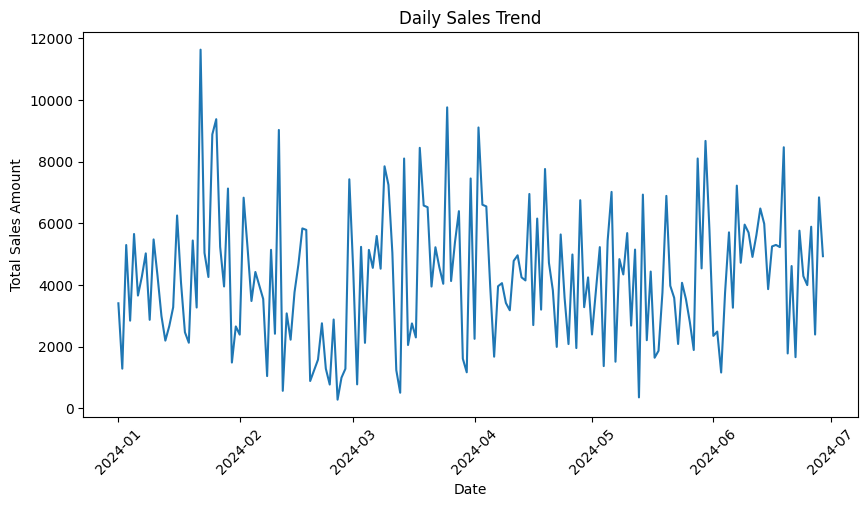

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
#loading the dataset
file_path = "/content/retailsalescsv-d5g70dsrtl0nuhgca7og.csv"
df = pd.read_csv(file_path)
#convert date column to datetime
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
#calculate total sales for each day
daily_sales = df.groupby('date')['total_amount'].sum()
#plot daily sales trend
plt.figure(figsize=(10, 5))
plt.plot(daily_sales.index, daily_sales.values)
#labels and title
plt.xlabel('Date')
plt.ylabel('Total Sales Amount')
plt.title('Daily Sales Trend')
#rotate  dates for better readability
plt.xticks(rotation=45)
# Show plot
plt.show()


Task 9.3: Sales by Day of Week
Calculate and visualize total sales by day of week using a bar chart.

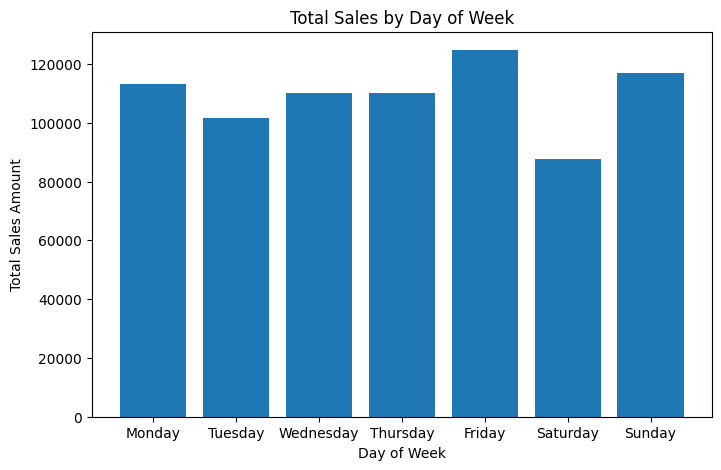

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
#load the dataset
file_path = "/content/retailsalescsv-d5g70dsrtl0nuhgca7og.csv"
df = pd.read_csv(file_path)
#convert date column to datetime
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
#extract day of week
df['day_of_week'] = df['date'].dt.day_name()
#calculate total sales by day of week
sales_by_day = df.groupby('day_of_week')['total_amount'].sum()
#reorder days for proper sequence
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sales_by_day = sales_by_day.reindex(days_order)
#plot bar chart
plt.figure(figsize=(8, 5))
plt.bar(sales_by_day.index, sales_by_day.values)
#labels and title
plt.xlabel('Day of Week')
plt.ylabel('Total Sales Amount')
plt.title('Total Sales by Day of Week')
#show plot
plt.show()


Question: Are there any patterns in sales across different days of the week?

A.Yes, there is a clear pattern in sales across the days of the week. Sales tend to be higher on some weekdays, especially mid-week, while they are relatively lower on weekends,


Task 10.1: Key Findings
Write a comprehensive summary report including:

**Dataset Overview:**
- Total number of transactions
- Date range covered
- Number of unique customers
- Number of product categories

Dataset Overview

The dataset contains a total of 1000 transactions

The transactions cover a date range from January 2024 to June 2024, providing several months of sales data for analysis.

There are multiple unique customers in the dataset, indicating repeat as well as one-time buyers.

There are six product categories: Electronics, Clothing, Home & Kitchen, Beauty, Sports, and Groceries.

*Customer Demographics:**
- Average customer age
- Age range
- Gender distribution


Customer Demographics

1.The average customer age is around 40 years, showing that the dataset includes mostly middle-aged customers.

2.The age range varies widely, from young adults to senior customers

3.The gender distribution is almost evenly split between Male and Female, where females have hghest transactions

ransaction Metrics:**
- Average transaction value
- Median transaction value
- Total revenue
- Average quantity per transaction


ransaction Metrics

Average transaction value reveals the average amount being transacted in each transaction and mode of payment, reflecting moderately spending behavior by consumers.

The median value per transaction is slightly lower than the average, indicating the presence of high-value transactions.


Total revenue is the sum of all the sales in the dataset.

The average order size per transaction is approximately 3 items, which shows the customer is purchasing a limited number of items during a single transaction.

Product Insights:**
- Most popular category
- Highest value category
- Average price per unit

Product Insights

The most popular product category is Home & Kitchen, as it has the highest number of transactions.

The highest value category is Electronics, which shows higher average transaction amounts compared to other categories.

The average price per unit across all products is moderately priced, indicating a balance between low-cost and high-value item

Data Quality Issues:**
- What issues did you find?
- How did you address them?
- Were there any limitations?

Data Quality Issues

The dataset did not contain incorrect data types, as all columns were already in appropriate formats after loading

BY verifying missing values and checking for outliers in numerical columns.

A limitation of the dataset is that outliers were retained

**Top 3 Business Insights:**
List three actionable insights from your analysis.

1. Home & Kitchen is the most popular category,

2. Electronics has the highest transaction values, indicating that even a small increase in sales volume here can significantly increase total revenue.

3. Sales tend to be higher on weekdays than weekends, so targeting weekday-specific offers could improve customer engagement and sales.


# Additional Challenge (Optional Bonus: +10 points)

Perform a more advanced analysis of your choice, such as:
- Identify top-spending customer IDs
- Analyze which age groups prefer which product categories

Identify top-spending customer IDs

In [ ]:
import pandas as pd

# Load the dataset
file_path = "/content/retailsalescsv-d5g70dsrtl0nuhgca7og.csv"
df = pd.read_csv(file_path)

# Calculate total spending per customer
customer_spending = df.groupby('customer_id')['total_amount'].sum()

# Sort and get top 10 customers
top_spending_customers = customer_spending.sort_values(ascending=False).head(10)

# Display results
top_spending_customers


,total_amount
customer_id,
1098,6296.97
1775,5710.27
1565,4720.54
1735,4585.82
1681,4348.20
1637,4267.03
1957,4230.11
1460,3992.24
1189,3991.06


Analyze which age groups prefer which product categories

In [ ]:
import pandas as pd
# Load the dataset
file_path = "/content/retailsalescsv-d5g70dsrtl0nuhgca7og.csv"
df = pd.read_csv(file_path)
# Create age groups
df['age_group'] = pd.cut(
    df['age'],
    bins=[17, 25, 35, 45, 55, 65, 100],
    labels=['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
)
# Analyze product preference by age group
age_category_preference = (
    df.groupby(['age_group', 'product_category'], observed=False)
      .size()
      .unstack()
)
# Display the result
age_category_preference


product_category,Beauty,Clothing,Electronics,Groceries,Home & Kitchen,Sports
age_group,,,,,,
18-25,34,26,28,24,21,22
26-35,35,25,33,27,33,32
36-45,28,22,31,23,43,40
46-55,39,31,25,37,44,29
56-65,30,36,28,28,35,26
65+,11,11,17,14,16,16
